<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Transfer Learning y Fine-Tuning: Reutilizar lo que Otro Modelo Ya Aprendió 🔁
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 08
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/08%20-%20Temas%20Avanzados%20de%20ML/01_Transfer_Learning_y_Fine_Tuning.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno desarrolla la **Sección 3.4** del libro (*Transfer learning and pre-trained model fine-tuning*). En el [Módulo 02, cuaderno 02](../02%20-%20Arboles%20Bosques%20y%20Redes%20Neuronales/02_Redes_Neuronales.ipynb) entrenamos redes **desde cero**; aquí nos preguntamos qué ocurre cuando tenemos **muy pocos ejemplos etiquetados** para la tarea que nos interesa pero sí disponemos de una red entrenada para **otra** tarea relacionada. La respuesta ingenua es «reutilízala»; la respuesta rigurosa es **«depende de qué capas reutilices, de cuánto cambies y de qué tan parecidas sean las tareas»**. Lo comprobamos con un experimento **100 % offline** en PyTorch, **con varias semillas** y reportando **también lo que no funciona**.

Al terminar podrás:

1. **Definir** el *transfer learning* (dominio y tarea de origen y de destino) y **distinguir** sus estrategias: **extracción de características**, ***fine-tuning* completo**, **congelar capas** y **tasas de aprendizaje diferenciales**.
2. **Explicar** por qué funciona: las **primeras capas** aprenden rasgos **generales** y las últimas, rasgos **específicos** de la tarea.
3. **Preentrenar** una CNN pequeña en una **tarea fuente** (dígitos 0–4) y **transferirla** a una **tarea destino distinta** (dígitos 5–9) con pocos ejemplos etiquetados.
4. **Comparar con rigor** (varias semillas, media ± desviación) entrenar **desde cero** frente a extraer características, *fine-tuning* y *fine-tuning* con tasa menor en el *backbone*, para distintos tamaños del conjunto destino.
5. **Medir** cuántas capas conviene reutilizar y **demostrar** que reutilizar la capa **demasiado específica** puede **destruir** el desempeño.
6. **Reconocer cuándo NO ayuda**: datos destino abundantes o tarea fácil, y **dominios distantes** (transferencia negativa).
7. **Usar** un modelo preentrenado real (`torchvision.models.resnet18`, **opcional y protegido**) y situar BERT y LoRA como contexto.

> 📍 **Dónde estamos:** Módulo 08, cuaderno 2 de 5. Venimos de la [Introducción al Capítulo 3](00_Introduccion_Cap3_y_Conceptos_Avanzados.ipynb). Siguientes: [Explicabilidad de modelos](02_Explicabilidad_de_Modelos.ipynb) → [Datasets desbalanceados](03_Datasets_Desbalanceados.ipynb) → [Datos faltantes](04_Datos_Faltantes.ipynb).

> 🔗 **Para no repetir:** la CNN y la retropropagación se explican en el [Módulo 02, cuaderno 02](../02%20-%20Arboles%20Bosques%20y%20Redes%20Neuronales/02_Redes_Neuronales.ipynb) (incluida la integración con PyTorch). Las aplicaciones de visión por computador y de lenguaje con modelos preentrenados (secciones 3.9 y 3.10 del libro) pertenecen al **Módulo 09**.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 11, sección *Reusing Pretrained Layers* (*Transfer Learning with PyTorch*, *Unsupervised Pretraining*, *Pretraining on an Auxiliary Task*); Cap. 12, secciones *Using TorchVision's Pretrained Models* y *Pretrained Models for Transfer Learning*; Cap. 15, *BERT Pretraining* y *BERT Fine-Tuning* (disponible en `Machine Learning/Libros/`; títulos verificados contra el índice del PDF).
- *Machine Learning with Python* — **Tarkeshwar Barua**. Cap. 7, secciones 7.10 (*Transfer Learning*), 7.11 (*Using Pretrained Models*) y 7.12 (*Fine-Tuning and Feature Extraction*) (disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- *Machine Learning for Engineers* — **Osvaldo Simeone**. Cap. 13, sección 13.2 (*Transfer Learning*) (disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- *Machine Learning Engineering with Python* (2.ª ed.) — **Andrew P. McMahon** (Packt). Cap. 7, sección *Fine-tuning and transfer learning* (disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- Yosinski, J., Clune, J., Bengio, Y. & Lipson, H. (2014), *How transferable are features in deep neural networks?*, **NeurIPS 27** — el estudio clásico de qué capas transfieren *(citado de memoria, verificar)*.
- Pan, S. J. & Yang, Q. (2010), *A survey on transfer learning*, **IEEE TKDE** 22(10): 1345–1359 *(citado de memoria, verificar)*.
- Howard, J. & Ruder, S. (2018), *Universal language model fine-tuning for text classification* (ULMFiT; tasas de aprendizaje discriminativas y descongelado gradual), **ACL** · Kumar, A. et al. (2022), *Fine-tuning can distort pretrained features and underperform out-of-distribution*, **ICLR** *(citados de memoria, verificar)*.
- Devlin, J. et al. (2019), *BERT: pre-training of deep bidirectional transformers for language understanding*, **NAACL** · Hu, E. et al. (2022), *LoRA: low-rank adaptation of large language models*, **ICLR** *(citados de memoria, verificar)*.
- He, K., Zhang, X., Ren, S. & Sun, J. (2016), *Deep residual learning for image recognition*, **CVPR** · Deng, J. et al. (2009), *ImageNet: a large-scale hierarchical image database*, **CVPR** *(citados de memoria, verificar)*.

### 🌐 Documentación y Recursos Online:
- [PyTorch: Transfer learning tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) · [`torch.optim`: parámetros por grupo (`param_groups`)](https://pytorch.org/docs/stable/optim.html#per-parameter-options)
- [torchvision: modelos y pesos preentrenados](https://pytorch.org/vision/stable/models.html)

---
## 1. Motivación y Taxonomía: Qué es Reutilizar un Modelo 🧭

### 1.1 El problema: pocos datos etiquetados

Etiquetar datos **cuesta** (tiempo de especialistas, dinero, privacidad). Entrenar una red profunda **desde cero** exige muchísimos ejemplos; con pocos, **sobreajusta**. Pero para muchas tareas existe una red entrenada con **millones** de ejemplos de otra tarea **relacionada**. El ***transfer learning*** aprovecha ese conocimiento (Pan y Yang, 2010). Formalmente, un **dominio** es $\mathcal D=\{\mathcal X, P(\mathbf x)\}$ y una **tarea** es $\mathcal T=\{\mathcal Y, P(y\mid\mathbf x)\}$. Con una **fuente** $(\mathcal D_S,\mathcal T_S)$ abundante y un **destino** $(\mathcal D_T,\mathcal T_T)$ escaso, buscamos **mejorar** el aprendizaje en el destino usando lo aprendido en la fuente, cuando $\mathcal D_S\neq\mathcal D_T$ o $\mathcal T_S\neq\mathcal T_T$.

### 1.2 Por qué funciona: la jerarquía de rasgos

En una red profunda las capas aprenden **rasgos de complejidad creciente**. En visión: las **primeras** capas detectan **bordes y manchas** (útiles para casi cualquier imagen), las **intermedias** combinan en **texturas y partes**, y las **últimas** responden a **conceptos específicos de la tarea** (p. ej. «el dígito 3»). Yosinski et al. (2014) mostraron que las capas iniciales son **generales** y las finales **específicas**, y que la transferencia **falla** cuando se reutilizan capas demasiado específicas.

### 1.3 Estrategias

Descomponemos los parámetros en un ***backbone*** $\theta_b$ (las capas reutilizadas, inicializadas con los pesos de la fuente $\theta_b^{(0)}$) y una **cabeza** $\theta_h$ (nueva, inicializada al azar y adaptada a las clases del destino):

| Estrategia | Qué se entrena | Cuándo tiene sentido |
|---|---|---|
| **Desde cero** (*scratch*) | Todo, con inicialización aleatoria | Muchos datos destino o tarea sin parecido con ninguna fuente |
| **Extracción de características** (*feature extraction*, *linear probing*) | **Solo la cabeza**: $\theta_b$ queda **congelado** en $\theta_b^{(0)}$ | Muy pocos datos; cómputo mínimo; menor riesgo de sobreajuste |
| ***Fine-tuning* completo** | Backbone **y** cabeza, con la misma tasa $\eta$ | Más datos y tareas parecidas; riesgo de **destruir** los rasgos preentrenados si $\eta$ es alta |
| ***Fine-tuning* con tasas diferenciales** | Backbone con $\eta_b=\eta/10$ (o menos) y cabeza con $\eta$ | Compromiso habitual: la cabeza aprende rápido y el backbone **se ajusta con delicadeza** (*discriminative learning rates*, Howard y Ruder, 2018) |
| **Congelar parcialmente** | Se congelan las primeras $k$ capas y se entrena el resto | Las primeras capas son las más generales; congelar **más** a menor cantidad de datos |

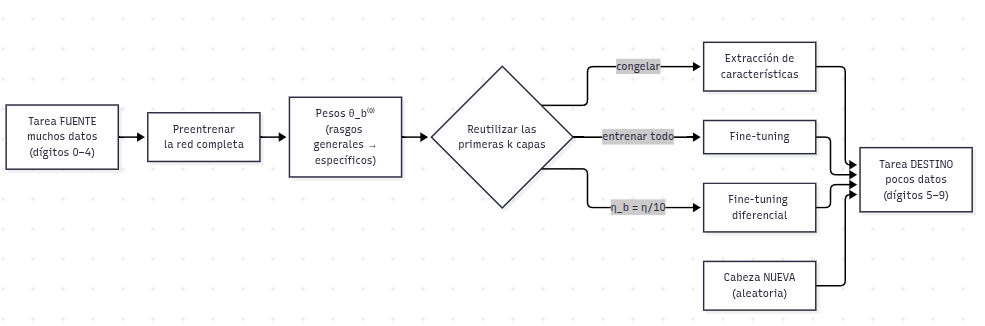

> 💡 **Una receta práctica habitual** (*LP-FT*, Kumar et al., 2022): **(1)** entrenar solo la cabeza con el backbone congelado; **(2)** descongelar y hacer *fine-tuning* con tasa pequeña. Así se evita que los gradientes **ruidosos** de una cabeza aleatoria distorsionen los rasgos del backbone. El *fine-tuning* con pocos pasos y tasa pequeña también actúa como **regularizador implícito**: mantiene $\theta_b$ **cerca** de $\theta_b^{(0)}$.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy torch

import time
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

try:
    import torch
    import torch.nn as nn
except ImportError as e:                                   # este cuaderno REQUIERE PyTorch (en Colab ya viene instalado)
    raise ImportError("Este cuaderno necesita PyTorch: ejecuta  !pip install torch  y reinicia el entorno.") from e

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.set_num_threads(2)                                   # redes diminutas: pocos hilos evitan sobrecarga y dan tiempos estables
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d", "#78350f", "#475569"]

# ---- Banderas del cuaderno ----
RAPIDO = True              # True: 4 semillas y tamaños 5-50 (~1 min). False: 10 semillas y tamaños 5-200 (~4-5 min): medias mas estables
USAR_PRETRAINED = False    # True SOLO con red (Colab): descarga ResNet-18 de ImageNet en la seccion 6 (opcional)
SEMILLAS = list(range(4 if RAPIDO else 10))
N_FIJO = 10                # tamano del destino usado en las secciones 4-6 (regimen donde la transferencia ayuda)
TAMANOS = [5, 10, 25, 50] if RAPIDO else [5, 10, 25, 50, 100, 200]
EPOCAS = 40 if RAPIDO else 60
print(f"Entorno listo | numpy {np.__version__} | scikit-learn {sklearn.__version__} | torch {torch.__version__}")
print(f"RAPIDO = {RAPIDO} | semillas = {len(SEMILLAS)} | tamaños del conjunto destino = {TAMANOS} | épocas = {EPOCAS}")

---
## 2. El Experimento: Del Dígito 0–4 al Dígito 5–9 🔬

**Datos.** Las imágenes $8\times8$ de `load_digits` (escaladas a $[0,1]$) con **ruido gaussiano** de desviación $\sigma=0.4$ (un sensor de baja calidad) sumado **una sola vez** y con semilla fija. Dos tareas **disjuntas**:

- **Fuente:** clasificar los dígitos **0–4** (≈ 900 imágenes etiquetadas; 720 para entrenar y 180 para validar).
- **Destino:** clasificar los dígitos **5–9** (clases **distintas**: ni una sola etiqueta en común), con solo $n\in\{5,10,25,50,\dots\}$ imágenes **etiquetadas** (estratificadas) y un **conjunto de prueba fijo** de 359 imágenes.

**Red.** Una CNN pequeña de **tres bloques** y una capa de salida: `conv(1→16)+ReLU` → `conv(16→32)+ReLU+MaxPool` → `Linear(512→64)+ReLU` → `Linear(64→5)`. Reutilizar $k$ bloques significa **copiar** los pesos de los primeros $k$ bloques de la red preentrenada y **reiniciar al azar** los demás y la capa de salida. Así $k=0$ es entrenar desde cero, $k=2$ reutiliza las **dos capas convolucionales** (rasgos visuales) y $k=3$ reutiliza **también** la capa densa, que ya es específica de la tarea fuente.

**Protocolo honesto:** por cada semilla se **preentrena una red** (la fuente es la misma, la inicialización cambia), se eligen **$n$ ejemplos destino** distintos, y se compara **todo con la misma tasa de aprendizaje, el mismo número de épocas y las mismas imágenes**. Se reporta **media ± desviación entre semillas**: con tan pocas semillas la desviación es una **guía**, no un intervalo de confianza formal.

In [ ]:
# ============================================================
# 2. Datos, red, utilidades y preentrenamiento en la tarea fuente
# ============================================================
SIGMA_RUIDO = 0.4


def preparar_datos(sigma, semilla_ruido=0):
    """Digitos 8x8 en [0,1] + ruido gaussiano fijo. Fuente = 0-4; destino = 5-9 (re-etiquetados 0-4); prueba destino fija."""
    d = load_digits()
    X = (d.data / 16.0).astype(np.float32)
    X = X + sigma * np.random.RandomState(semilla_ruido).randn(*X.shape).astype(np.float32)
    X = X.reshape(-1, 1, 8, 8)
    y = d.target
    Xf, yf = X[y <= 4], y[y <= 4]                         # tarea FUENTE: digitos 0-4
    Xd, yd = X[y >= 5], y[y >= 5] - 5                     # tarea DESTINO: digitos 5-9 (etiquetas 0-4 sin relacion con las de la fuente)
    Xf_ent, Xf_val, yf_ent, yf_val = train_test_split(Xf, yf, test_size=0.2, stratify=yf, random_state=0)
    Xd_pool, Xd_te, yd_pool, yd_te = train_test_split(Xd, yd, test_size=0.4, stratify=yd, random_state=0)
    return dict(Xf_ent=Xf_ent, yf_ent=yf_ent, Xf_val=Xf_val, yf_val=yf_val, Xd_pool=Xd_pool, yd_pool=yd_pool, Xd_te=Xd_te, yd_te=yd_te)


class Red(nn.Module):
    """CNN de 3 bloques + salida. Los bloques son las unidades que se copian al transferir."""
    def __init__(self):
        super().__init__()
        self.bloques = nn.ModuleList([
            nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU()),                                   # bloque 1: bordes/manchas (general)
            nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Flatten()),   # bloque 2: combinaciones locales
            nn.Sequential(nn.Linear(512, 64), nn.ReLU()),                                               # bloque 3: densa (mas especifica)
        ])
        self.salida = nn.Linear(64, 5)                                                                  # cabeza: depende de las clases

    def forward(self, x):
        for b in self.bloques:
            x = b(x)
        return self.salida(x)


def entrenar(modelo, X, y, grupos, epocas, semilla, batch=32):
    """Adam por mini-lotes. `grupos` = lista de param_groups (permite tasas de aprendizaje distintas por grupo)."""
    opt = torch.optim.Adam(grupos)
    g = torch.Generator().manual_seed(semilla)
    X, y = torch.as_tensor(X), torch.as_tensor(y)
    n = len(X)
    modelo.train()
    for _ in range(epocas):
        orden = torch.randperm(n, generator=g)
        for i in range(0, n, min(batch, n)):
            idx = orden[i:i + batch]
            opt.zero_grad()
            nn.functional.cross_entropy(modelo(X[idx]), y[idx]).backward()
            opt.step()
    return modelo


def exactitud(modelo, X, y):
    modelo.eval()
    with torch.no_grad():
        return float((modelo(torch.as_tensor(X)).argmax(1).numpy() == y).mean())


def preentrenar(D, semilla, epocas=15):
    """Entrena la red completa en la tarea FUENTE (lotes de 64 para que sea rapido)."""
    torch.manual_seed(semilla)
    m = Red()
    return entrenar(m, D["Xf_ent"], D["yf_ent"], [{"params": m.parameters(), "lr": 1e-3}], epocas, semilla, batch=64)


def transferir(origen, k, semilla):
    """Red nueva: copia los k primeros bloques de `origen`; el resto y la salida se inicializan al azar (semilla propia)."""
    torch.manual_seed(2000 + semilla)
    m = Red()
    for i in range(k):
        m.bloques[i].load_state_dict(origen.bloques[i].state_dict())
    return m


def ajustar_destino(D, origen, k, modo, n, semilla, lr=1e-3, epocas=None):
    """Entrena en el DESTINO con n ejemplos etiquetados. modo: 'scratch' | 'congelar' | 'ft' | 'ft_dif'. Devuelve (exactitud en prueba, modelo)."""
    epocas = epocas or EPOCAS
    Xa, _, ya, _ = train_test_split(D["Xd_pool"], D["yd_pool"], train_size=n, stratify=D["yd_pool"], random_state=semilla)
    if modo == "scratch":
        k = 0
    torch.manual_seed(1000 + semilla)
    m = transferir(origen, k, semilla) if k > 0 else Red()
    backbone = [p for b in m.bloques[:k] for p in b.parameters()]
    resto = [p for b in m.bloques[k:] for p in b.parameters()] + list(m.salida.parameters())
    if modo == "congelar":
        for p in backbone:
            p.requires_grad = False                          # el backbone no recibe gradiente ni se actualiza
        grupos = [{"params": resto, "lr": lr}]
    elif modo == "ft_dif" and k > 0:
        grupos = [{"params": backbone, "lr": lr / 10}, {"params": resto, "lr": lr}]     # tasa diferencial: backbone 10 veces menor
    else:
        grupos = [{"params": m.parameters(), "lr": lr}]
    entrenar(m, Xa, ya, grupos, epocas, semilla)
    return exactitud(m, D["Xd_te"], D["yd_te"]), m


# ---------- Preentrenamiento (una red por semilla) ----------
t0 = time.time()
D = preparar_datos(SIGMA_RUIDO)
preentrenadas = [preentrenar(D, s) for s in SEMILLAS]
acc_fuente = [exactitud(m, D["Xf_val"], D["yf_val"]) for m in preentrenadas]
print(f"Preentrenamiento en la tarea fuente (dígitos 0-4, validación): {np.mean(acc_fuente):.3f} ± {np.std(acc_fuente):.3f}  [{time.time() - t0:.1f} s]")

# ---------- Verificaciones estructurales (lo que SIGNIFICA 'transferir' y 'congelar') ----------
origen = preentrenadas[0]
m_t = transferir(origen, 2, 0)
assert all(torch.equal(a, b) for i in range(2) for a, b in zip(m_t.bloques[i].state_dict().values(), origen.bloques[i].state_dict().values()))   # copiados
assert not torch.equal(m_t.bloques[2][0].weight, origen.bloques[2][0].weight)                                                                      # el bloque 3 es nuevo

antes = [p.detach().clone() for b in origen.bloques[:2] for p in b.parameters()]
_, m_cong = ajustar_destino(D, origen, 2, "congelar", 25, 0)
despues = [p.detach() for b in m_cong.bloques[:2] for p in b.parameters()]
assert all(torch.equal(a, b) for a, b in zip(antes, despues))                                   # congelado: IDENTICO tras entrenar
_, m_ft = ajustar_destino(D, origen, 2, "ft", 25, 0)
cambio = float(np.mean([(b.detach() - a).norm() / a.norm() for a, b in zip(antes, [p for bl in m_ft.bloques[:2] for p in bl.parameters()])]))
assert cambio > 1e-3                                                                            # fine-tuning: el backbone SI cambia
n_tot = sum(p.numel() for p in m_cong.parameters()); n_ent = sum(p.numel() for p in m_cong.parameters() if p.requires_grad)
print(f"Backbone congelado: idéntico tras entrenar (verificado). Parámetros entrenables: {n_ent:,} de {n_tot:,} ({100 * n_ent / n_tot:.0f} %).")
print(f"Con fine-tuning completo, el backbone cambia en promedio {100 * cambio:.2f} % de su norma respecto a los pesos preentrenados.")
assert np.mean(acc_fuente) > 0.8                         # la red aprende la tarea fuente (con ruido, ~0.87)

---
##### 🛠️ Práctica 1: Contar qué se entrena al congelar: parámetros por profundidad $k$

Congelar un *backbone* significa que sus parámetros **no se actualizan**. Con la clase `Red`, la función `transferir` y la lista `preentrenadas` (la red preentrenada de la semilla 0 es `preentrenadas[0]`), cuenta cuántos parámetros quedan **entrenables** según cuántos bloques copies y congeles:

1. Para cada $k\in\{0,1,2,3\}$ crea `m = transferir(preentrenadas[0], k, 0)` y pon `requires_grad = False` en los parámetros de sus **primeros $k$ bloques** (`m.bloques[:k]`).
2. Guarda en un `DataFrame` llamado `tabla_params` (índice = $k$) las columnas `congelados`, `entrenables` y `% entrenable` (sobre el total de parámetros de la red).
3. Verifica con `assert` que el total es siempre $37\,957$, que con $k=0$ todo es entrenable, que con $k=2$ hay $4\,800$ parámetros congelados y que con $k=3$ solo la capa de salida ($325$ parámetros) es entrenable.
4. Comenta: ¿por qué el caso $k=3$ congelado de la Sección 4 deja a la cabeza tan limitada?

In [ ]:
# Escribe tu código aquí

# filas = {}
# for k in range(4):
#     m = transferir(preentrenadas[0], k, 0)
#     for b in m.bloques[:k]:
#         for p in b.parameters():
#             p.requires_grad = ...
#     total = sum(p.numel() for p in m.parameters())
#     congelados = sum(p.numel() for p in m.parameters() if not p.requires_grad)
#     filas[k] = {"congelados": congelados, "entrenables": total - congelados, "% entrenable": ...}
# tabla_params = pd.DataFrame(filas).T


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
filas = {}
for k in range(4):
    m = transferir(preentrenadas[0], k, 0)
    for b in m.bloques[:k]:                          # congelar = que el optimizador ya no actualice esos parametros
        for p in b.parameters():
            p.requires_grad = False
    total = sum(p.numel() for p in m.parameters())
    congelados = sum(p.numel() for p in m.parameters() if not p.requires_grad)
    filas[k] = {"total": total, "congelados": congelados, "entrenables": total - congelados,
                "% entrenable": 100 * (total - congelados) / total}

tabla_params = pd.DataFrame(filas).T
tabla_params.index.name = "k"
display(tabla_params.round(1))

assert (tabla_params["total"] == 37957).all()
assert tabla_params.loc[0, "entrenables"] == 37957
assert tabla_params.loc[2, "congelados"] == 160 + 4640           # conv1 (1*16*9+16) + conv2 (16*32*9+32)
assert tabla_params.loc[3, "entrenables"] == 325                 # solo la capa de salida: 64*5 + 5
print("Con k = 3 solo se entrena una capa lineal sobre 64 rasgos ya especializados en los dígitos 0-4: no puede deshacerlos.")
```
</details>

---


---
## 3. Resultado Principal: Cuatro Estrategias, Distintos Tamaños del Conjunto Destino 📊

Comparamos las cuatro estrategias reutilizando **$k=2$ bloques** (las dos capas convolucionales; la capa densa y la salida son nuevas):

1. **Desde cero** (`scratch`).
2. **Extracción de características** (`congelar`): backbone congelado, se entrena solo lo nuevo.
3. ***Fine-tuning* completo** (`ft`): misma tasa $\eta=10^{-3}$ para todo.
4. ***Fine-tuning* diferencial** (`ft_dif`): $\eta_b=\eta/10$ en el backbone y $\eta$ en lo nuevo.

Cada punto es la **media sobre las semillas** de la exactitud en la **misma prueba destino fija**; las bandas son $\pm$ una desviación estándar. Como cada semilla usa **los mismos $n$ ejemplos** para las cuatro estrategias, también reportamos la **diferencia pareada** frente a `scratch`.

In [ ]:
# ============================================================
# 3. Experimento principal: scratch vs feature extraction vs fine-tuning vs fine-tuning diferencial
# ============================================================
t0 = time.time()
MODOS = {"scratch": "Desde cero", "congelar": "Extracción de características", "ft": "Fine-tuning completo", "ft_dif": "Fine-tuning (backbone η/10)"}
filas = []
for s in SEMILLAS:
    for n in TAMANOS:
        for modo in MODOS:
            a, _ = ajustar_destino(D, preentrenadas[s], 2, modo, n, s)
            filas.append({"semilla": s, "n": n, "modo": modo, "acc": a})
df_a = pd.DataFrame(filas)
media = df_a.groupby(["n", "modo"]).acc.mean().unstack()[list(MODOS)]
desv = df_a.groupby(["n", "modo"]).acc.std(ddof=0).unstack()[list(MODOS)]
tabla = media.round(3).astype(str) + " ± " + desv.round(3).astype(str)
tabla.columns = list(MODOS.values())
tabla.index.name = "n etiquetados (destino)"
display(tabla)

piv = df_a.pivot_table(index=["semilla", "n"], columns="modo", values="acc")
ganancia = pd.DataFrame({MODOS[m]: (piv[m] - piv["scratch"]).groupby("n").mean() for m in ["congelar", "ft", "ft_dif"]})
ganancia_ee = pd.DataFrame({MODOS[m]: (piv[m] - piv["scratch"]).groupby("n").std(ddof=0) for m in ["congelar", "ft", "ft_dif"]})
print("\nGanancia pareada frente a entrenar desde cero (puntos porcentuales; media entre semillas):")
display((100 * ganancia).round(1))
print(f"[{time.time() - t0:.0f} s]")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for c, (modo, nombre) in zip(PALETA, MODOS.items()):
    axes[0].plot(TAMANOS, media[modo], "o-", color=c, lw=2, label=nombre)
    axes[0].fill_between(TAMANOS, media[modo] - desv[modo], media[modo] + desv[modo], color=c, alpha=0.12)
axes[0].set_xscale("log"); axes[0].set_xticks(TAMANOS); axes[0].set_xticklabels(TAMANOS); axes[0].minorticks_off()
axes[0].set_xlabel("Ejemplos etiquetados de la tarea destino ($n$, escala log)"); axes[0].set_ylabel(f"Exactitud en la prueba destino (media de {len(SEMILLAS)} semillas)")
axes[0].set_title("Dígitos 5–9 con la CNN preentrenada en 0–4", fontweight="bold", fontsize=10); axes[0].legend(fontsize=8)
for c, col in zip(PALETA[1:], ganancia.columns):
    axes[1].errorbar(TAMANOS, 100 * ganancia[col], yerr=100 * ganancia_ee[col], fmt="o-", color=c, lw=2, capsize=3, label=col)
axes[1].axhline(0, color="black", lw=1); axes[1].set_xscale("log"); axes[1].set_xticks(TAMANOS); axes[1].set_xticklabels(TAMANOS); axes[1].minorticks_off()
axes[1].set_xlabel("Ejemplos etiquetados de la tarea destino ($n$)"); axes[1].set_ylabel("Ganancia sobre 'desde cero' (puntos %)")
axes[1].set_title("Ganancia por transferir (barras: ±1 desv. entre semillas)", fontweight="bold", fontsize=10); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

n_peq = TAMANOS[0]
print(f"Con n = {n_peq}: desde cero = {media.loc[n_peq, 'scratch']:.3f}; mejor estrategia con transferencia = {media.loc[n_peq, ['congelar', 'ft', 'ft_dif']].max():.3f}.")
print(f"Con n = {TAMANOS[-1]}: desde cero = {media.loc[TAMANOS[-1], 'scratch']:.3f}; mejor con transferencia = {media.loc[TAMANOS[-1], ['congelar', 'ft', 'ft_dif']].max():.3f}  (la ventaja se acaba al crecer n).")
assert media.shape == (len(TAMANOS), 4) and np.isfinite(media.values).all()
assert (media.values > 0.2).all()                          # todas las estrategias aprenden algo (azar = 0.20 en 5 clases)

---
**Lectura honesta del resultado principal.** Con las imágenes ruidosas, **reutilizar las capas convolucionales ayuda cuando el destino tiene muy pocos ejemplos** (una ganancia de **varios puntos** con $n\in\{5,10\}$) y **la ventaja se desvanece al crecer $n$**: con 25 ejemplos el entrenamiento desde cero ya la alcanza (la diferencia es menor que la desviación entre semillas). Observa también lo que **no** ocurre: **extraer características, *fine-tuning* completo y *fine-tuning* diferencial dan casi lo mismo** con una tasa de aprendizaje razonable ($10^{-3}$); las diferencias entre ellos son **menores que la desviación entre semillas**. El *fine-tuning* **solo importa** cuando la tasa de aprendizaje es agresiva (sección 5). Y las ganancias son **modestas** (puntos, no decenas de puntos): la tarea fuente y la destino comparten **rasgos visuales simples** de imágenes diminutas, no millones de ejemplos de ImageNet.

---

## 4. ¿Cuántas Capas Reutilizar? Rasgos Generales frente a Específicos 🧅

La teoría dice que las **primeras capas son generales** y las **últimas específicas**. Lo comprobamos variando $k$ (número de bloques copiados) con $n=10$ ejemplos destino (el régimen donde la transferencia sí ayudó):

- $k=1$: solo la **primera capa convolucional** (bordes y manchas).
- $k=2$: las **dos capas convolucionales**.
- $k=3$: **también la capa densa**, que ya codifica combinaciones útiles para distinguir **los dígitos 0–4**.

Para cada $k$ se prueban **congelar** el backbone y ***fine-tuning*** completo. El caso $k=3$ **congelado** es el más revelador: la capa densa produce 64 rasgos **ajustados a otras clases**, y la nueva cabeza debe clasificar los dígitos 5–9 **solo con ellos**. Además se dibujan los **16 filtros** de la primera capa (preentrenados frente a inicialización aleatoria) y se mide **cuánto se mueve** el backbone con cada estrategia.

In [ ]:
# ============================================================
# 4. Profundidad de la reutilizacion (k) y filtros de la primera capa
# ============================================================
t0 = time.time()
N_B = N_FIJO
filas = []
for s in SEMILLAS:
    filas.append({"k": 0, "modo": "desde cero", "semilla": s, "acc": ajustar_destino(D, preentrenadas[s], 0, "scratch", N_B, s)[0]})
    for k in (1, 2, 3):
        for modo, etiqueta in (("congelar", "congelar"), ("ft", "fine-tuning")):
            filas.append({"k": k, "modo": etiqueta, "semilla": s, "acc": ajustar_destino(D, preentrenadas[s], k, modo, N_B, s)[0]})
df_b = pd.DataFrame(filas)
res_b = df_b.groupby(["k", "modo"]).acc.agg(["mean", "std"]).round(3)
res_b["std"] = df_b.groupby(["k", "modo"]).acc.std(ddof=0).round(3)
res_b.columns = ["media", "desv."]
display(res_b.T)
print(f"[{time.time() - t0:.0f} s]")

m_cero = float(df_b[df_b.k == 0].acc.mean())
m3_cong = float(df_b[(df_b.k == 3) & (df_b.modo == "congelar")].acc.mean())
m2_cong = float(df_b[(df_b.k == 2) & (df_b.modo == "congelar")].acc.mean())
assert m3_cong < m_cero - 0.1                              # reutilizar y congelar la capa especifica DESTRUYE el desempeno (transferencia negativa)
print(f"k = 3 congelado: {m3_cong:.3f} frente a {m_cero:.3f} desde cero y {m2_cong:.3f} con k = 2: reutilizar la capa específica perjudica.")

# --- Filtros de la primera capa: preentrenados vs aleatorios, y cuanto cambian con cada estrategia ---
torch.manual_seed(0)
w_pre = preentrenadas[0].bloques[0][0].weight.detach().numpy().reshape(16, 3, 3)
w_alea = Red().bloques[0][0].weight.detach().numpy().reshape(16, 3, 3)
_, m_ft = ajustar_destino(D, preentrenadas[0], 2, "ft", N_B, 0, lr=1e-2)
_, m_dif = ajustar_destino(D, preentrenadas[0], 2, "ft_dif", N_B, 0, lr=1e-2)
w_ft = m_ft.bloques[0][0].weight.detach().numpy().reshape(16, 3, 3)
w_dif = m_dif.bloques[0][0].weight.detach().numpy().reshape(16, 3, 3)
rel = lambda w: np.linalg.norm(w - w_pre) / np.linalg.norm(w_pre)

fig, axes = plt.subplots(4, 16, figsize=(16, 4.6))
for fila, (w, titulo) in enumerate([(w_alea, "Aleatorios (inicio)"), (w_pre, "Preentrenados (fuente)"),
                                     (w_ft, f"Tras fine-tuning η=1e-2\n(cambio {100 * rel(w_ft):.0f} %)"), (w_dif, f"Tras fine-tuning dif.\n(cambio {100 * rel(w_dif):.0f} %)")]):
    v = np.abs(w).max()
    for j in range(16):
        axes[fila, j].imshow(w[j], cmap="RdBu_r", vmin=-v, vmax=v); axes[fila, j].axis("off")
    axes[fila, 0].text(-0.2, 0.5, titulo, transform=axes[fila, 0].transAxes, ha="right", va="center", fontsize=8)
fig.suptitle("Los 16 filtros 3×3 de la primera capa convolucional", fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()
print(f"Cambio relativo de los filtros respecto a los preentrenados con η = 1e-2: fine-tuning completo {100 * rel(w_ft):.0f} % | diferencial {100 * rel(w_dif):.0f} %.")
assert rel(w_dif) < rel(w_ft)                              # la tasa diferencial protege los rasgos preentrenados

---
**Lectura de la profundidad.** Reutilizar **una o dos capas convolucionales** da una **ganancia moderada** frente a empezar desde cero. En cambio, reutilizar **y congelar** la capa densa ($k=3$) **desploma** la exactitud muy por debajo de entrenar desde cero: esa capa produce rasgos **especializados en distinguir los dígitos 0–4**, y la nueva cabeza **no puede deshacerlos**. Con *fine-tuning* ($k=3$ entrenable) la red puede **corregirse**, y queda aproximadamente donde empezaría desde cero: ya **no gana** nada. Es la **transferencia negativa** por reutilizar **demasiado**: la regla práctica es **congelar lo general y reentrenar lo específico**. Los filtros dibujados muestran que, tras el preentrenamiento, los de la primera capa **se parecen a detectores de bordes y manchas**, y que la **tasa diferencial los deja más cerca** de su valor preentrenado que el *fine-tuning* completo.

---

## 5. Tasas de Aprendizaje Diferenciales: la Razón de Ser del *Fine-Tuning* Cuidadoso 🎚️

Con $\eta=10^{-3}$ las tres estrategias de transferencia eran equivalentes. La diferencia aparece cuando la tasa de aprendizaje **no es la adecuada**. La actualización de Adam para el *backbone* es $\theta_b\leftarrow\theta_b-\eta_b\,\hat m/(\sqrt{\hat v}+\epsilon)$: con $\eta_b$ **grande**, los primeros pasos —guiados por una **cabeza aleatoria** que aún **no sabe nada**— producen gradientes ruidosos que **deshacen** los rasgos preentrenados. Con una $\eta_b$ pequeña (**$\eta/10$**), el backbone **solo se ajusta con delicadeza**.

Barremos $\eta\in\{10^{-4},10^{-3},10^{-2},3\cdot10^{-2}\}$ con $n=25$ (aquí no nos interesa la ganancia sino la **sensibilidad** a la tasa), reutilizando $k=2$ bloques, para: desde cero, *fine-tuning* completo, *fine-tuning* diferencial y extracción de características.

In [ ]:
# ============================================================
# 5. Sensibilidad a la tasa de aprendizaje: scratch vs fine-tuning vs fine-tuning diferencial vs congelar
# ============================================================
t0 = time.time()
LRS = [1e-4, 1e-3, 1e-2, 3e-2]
N_C = 25                                                   # aqui n = 25: no importa la ganancia sino la SENSIBILIDAD a la tasa
filas = []
for s in SEMILLAS:
    for lr in LRS:
        for modo in MODOS:
            filas.append({"semilla": s, "lr": lr, "modo": modo, "acc": ajustar_destino(D, preentrenadas[s], 2, modo, N_C, s, lr=lr)[0]})
df_c = pd.DataFrame(filas)
mc = df_c.groupby(["lr", "modo"]).acc.mean().unstack()[list(MODOS)]
sc = df_c.groupby(["lr", "modo"]).acc.std(ddof=0).unstack()[list(MODOS)]
t_lr = mc.round(3).astype(str) + " ± " + sc.round(3).astype(str)
t_lr.columns = list(MODOS.values()); t_lr.index.name = "tasa de aprendizaje η"
display(t_lr)
print(f"[{time.time() - t0:.0f} s]")

fig, ax = plt.subplots(figsize=(9, 4.6))
for c, (modo, nombre) in zip(PALETA, MODOS.items()):
    ax.errorbar(LRS, mc[modo], yerr=sc[modo], fmt="o-", color=c, lw=2, capsize=3, label=nombre)
ax.set_xscale("log"); ax.set_xlabel("Tasa de aprendizaje $\\eta$ (escala log)"); ax.set_ylabel(f"Exactitud en la prueba destino (n = {N_C}, {len(SEMILLAS)} semillas)")
ax.set_title("Con η alta, el fine-tuning completo destruye los rasgos; el diferencial los protege", fontweight="bold", fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Con η = 3e-2: fine-tuning completo = {mc.loc[3e-2, 'ft']:.3f} | diferencial = {mc.loc[3e-2, 'ft_dif']:.3f} | extracción = {mc.loc[3e-2, 'congelar']:.3f} | desde cero = {mc.loc[3e-2, 'scratch']:.3f}")
print(f"Con η = 1e-4: desde cero = {mc.loc[1e-4, 'scratch']:.3f} (aún sin converger en {EPOCAS} épocas) frente a {mc.loc[1e-4, 'ft']:.3f} con transferencia.")
assert mc.loc[3e-2, "ft_dif"] > mc.loc[3e-2, "ft"] + 0.05          # con tasa agresiva, la diferencial salva lo que el fine-tuning completo destruye

---
**Lectura de la tasa de aprendizaje.** Dos hallazgos nítidos: **(1)** con una $\eta$ **agresiva** ($3\cdot10^{-2}$) el *fine-tuning* completo **colapsa** (los rasgos preentrenados se destruyen y la red queda **por debajo** incluso de entrenar desde cero), mientras que el **diferencial** y la **extracción de características** siguen funcionando. **(2)** con una $\eta$ **muy pequeña** ($10^{-4}$) la red **desde cero** casi no ha aprendido en el mismo número de épocas, mientras que las inicializadas con rasgos preentrenados **ya parten de un buen punto**: transferir **también acelera la convergencia** y reduce la sensibilidad a la tasa. Por eso la práctica estándar es **tasa pequeña para el backbone y mayor para la cabeza**.

---

## 6. ¿Cuándo NO Ayuda? Tarea Fácil y Dominios Distantes ⛔

El *transfer learning* **no es gratis ni universal**. Dos situaciones donde no ayuda (o perjudica):

1. **El destino ya es fácil con pocos datos.** Si las imágenes están **limpias** ($\sigma=0$), un clasificador desde cero ya acierta mucho con $n=10$ (≈ 0.86) y **queda poco margen** para ganar; los rasgos de la fuente son **innecesarios** y pueden incluso **sesgar**.
2. **Dominio distante** (*transferencia negativa*). Si las imágenes de la fuente tienen una **estructura espacial distinta** a las del destino, los filtros aprendidos **no sirven**. Lo simulamos con una fuente cuyos **píxeles se barajan con una permutación fija**: la red aprende a distinguir 0–4 igual de bien, pero con **rasgos sin significado espacial**.

Probamos ambas con $n=10$ (donde la fuente útil sí ayudó): desde cero frente a reutilizar $k=2$ con *fine-tuning*.

In [ ]:
# ============================================================
# 6. Cuando NO ayuda: destino facil (imagenes limpias) y dominio distante (pixeles permutados en la fuente)
# ============================================================
t0 = time.time()
# (i) destino facil: sin ruido
D_lim = preparar_datos(0.0)
pre_lim = [preentrenar(D_lim, s) for s in SEMILLAS]
# (ii) dominio distante: fuente con pixeles permutados (misma permutacion fija); el destino sigue siendo el normal
perm = np.random.RandomState(7).permutation(64)
D_perm = dict(D)
D_perm["Xf_ent"] = D["Xf_ent"].reshape(-1, 64)[:, perm].reshape(-1, 1, 8, 8).copy()
pre_perm = [preentrenar(D_perm, s) for s in SEMILLAS]

filas = []
for s in SEMILLAS:
    filas.append({"semilla": s, "escenario": "Destino fácil (imágenes limpias)", "estrategia": "Desde cero", "acc": ajustar_destino(D_lim, pre_lim[s], 0, "scratch", N_FIJO, s)[0]})
    filas.append({"semilla": s, "escenario": "Destino fácil (imágenes limpias)", "estrategia": "Transferencia (k=2, fine-tuning)", "acc": ajustar_destino(D_lim, pre_lim[s], 2, "ft", N_FIJO, s)[0]})
    filas.append({"semilla": s, "escenario": "Dominio distante (fuente con píxeles barajados)", "estrategia": "Desde cero", "acc": ajustar_destino(D, pre_perm[s], 0, "scratch", N_FIJO, s)[0]})
    filas.append({"semilla": s, "escenario": "Dominio distante (fuente con píxeles barajados)", "estrategia": "Transferencia (k=2, fine-tuning)", "acc": ajustar_destino(D, pre_perm[s], 2, "ft", N_FIJO, s)[0]})
    filas.append({"semilla": s, "escenario": "Referencia: fuente útil (imágenes ruidosas)", "estrategia": "Desde cero", "acc": ajustar_destino(D, preentrenadas[s], 0, "scratch", N_FIJO, s)[0]})
    filas.append({"semilla": s, "escenario": "Referencia: fuente útil (imágenes ruidosas)", "estrategia": "Transferencia (k=2, fine-tuning)", "acc": ajustar_destino(D, preentrenadas[s], 2, "ft", N_FIJO, s)[0]})
df_d = pd.DataFrame(filas)
pv = df_d.pivot_table(index=["escenario", "semilla"], columns="estrategia", values="acc")
dif = (pv["Transferencia (k=2, fine-tuning)"] - pv["Desde cero"]).groupby("escenario")
resumen = pd.DataFrame({"desde cero": pv["Desde cero"].groupby("escenario").mean(), "con transferencia": pv["Transferencia (k=2, fine-tuning)"].groupby("escenario").mean(),
                        "ganancia (pts)": 100 * dif.mean(), "± desv. (pts)": 100 * dif.std(ddof=0), "semillas con ganancia > 0": dif.apply(lambda v: f"{(v > 0).sum()}/{len(v)}")})
display(resumen.round(3))
print(f"[{time.time() - t0:.0f} s]")

fig, ax = plt.subplots(figsize=(9.5, 4.4))
orden = ["Referencia: fuente útil (imágenes ruidosas)", "Destino fácil (imágenes limpias)", "Dominio distante (fuente con píxeles barajados)"]
ax.bar(np.arange(3), resumen.loc[orden, "ganancia (pts)"], yerr=resumen.loc[orden, "± desv. (pts)"], color=[PALETA[2], PALETA[3], PALETA[1]], capsize=4)
ax.axhline(0, color="black", lw=1); ax.set_xticks(np.arange(3)); ax.set_xticklabels(["Fuente útil,\ndestino difícil", "Destino fácil\n(imágenes limpias)", "Dominio distante\n(píxeles barajados)"])
ax.set_ylabel(f"Ganancia de la transferencia (puntos %, n = {N_FIJO})")
ax.set_title("La transferencia ayuda donde hay algo que transferir… y no siempre", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()
print("Ganancias medias (puntos):", {k: round(float(v), 1) for k, v in resumen["ganancia (pts)"].items()})
assert resumen.loc["Referencia: fuente útil (imágenes ruidosas)", "ganancia (pts)"] > resumen.loc["Destino fácil (imágenes limpias)", "ganancia (pts)"]
assert resumen.loc["Referencia: fuente útil (imágenes ruidosas)", "ganancia (pts)"] > resumen.loc["Dominio distante (fuente con píxeles barajados)", "ganancia (pts)"]

---
**Lectura de los casos adversos.** Con una **fuente útil** y un destino difícil (imágenes ruidosas) hay una ganancia pequeña pero **consistente** (≈ +4 puntos, positiva en las 4 semillas); con un **destino fácil** (imágenes limpias) la ganancia **desaparece e incluso es ligeramente negativa** (≈ −1 punto): desde cero ya aprende bien y los rasgos de la fuente no aportan; y con un **dominio distante** (píxeles barajados) la transferencia **no ayuda** (≈ 0, indistinguible del ruido entre semillas; con otros tamaños de $n$ puede incluso perjudicar levemente). La desviación entre semillas (2–3 puntos) es comparable a estas diferencias, así que conviene **no sobreinterpretar** décimas de punto: lo importante es el **patrón** (cuándo hay ventaja y cuándo no) y **repetir con más semillas** (`RAPIDO = False`) antes de concluir. En la práctica, antes de adoptar el *transfer learning* **mide siempre** contra la línea base **desde cero** con el mismo presupuesto de datos.

---

## 7. Un Modelo Preentrenado de Verdad: ResNet-18 de ImageNet (Opcional) 🌐

Todo lo anterior fue **offline** y con una red diminuta. El caso real usa redes **grandes preentrenadas con millones de imágenes** (**ImageNet**, Deng et al., 2009; **ResNet**, He et al., 2016). Con `torchvision` el flujo es:

1. Cargar `models.resnet18(weights=...)` (la **primera vez descarga ≈ 45 MB** de pesos de ImageNet: **requiere red**).
2. **Reemplazar la cabeza**: `resnet.fc = nn.Linear(512, n_clases)` (la original tiene 1000 salidas, una por clase de ImageNet).
3. **Congelar** el resto (`requires_grad = False`, modo `eval()`) y extraer los **512 rasgos** de cada imagen.
4. Entrenar solo la cabeza (extracción de características) o descongelar con tasa pequeña (*fine-tuning*). La entrada se **normaliza con la media y desviación de ImageNet** y se replica a **3 canales**.

> ⚠️ **Este bloque NO se ejecuta por defecto** (`USAR_PRETRAINED = False` en la primera celda): necesita `torchvision` y **conexión a internet** para bajar los pesos (en Google Colab funciona directamente). Está protegido con `try/except`: si no hay red, imprime un aviso y el cuaderno **sigue** sin errores. Aquí lo aplicamos a los **dígitos 5–9 ampliados a 64×64** (ImageNet son fotografías de objetos: dígitos de 8×8 son un dominio **muy distinto**, así que **no esperes milagros**: es una demostración del **mecanismo**).

In [ ]:
# ============================================================
# 7. (OPCIONAL, requiere red) ResNet-18 preentrenada en ImageNet: reemplazar fc, congelar y extraer caracteristicas
# ============================================================
if USAR_PRETRAINED:
    try:
        import torchvision
        from torchvision import models
        t0 = time.time()
        pesos = models.ResNet18_Weights.DEFAULT                      # pesos de ImageNet (descarga ~45 MB la primera vez)
        resnet = models.resnet18(weights=pesos)
        resnet.fc = nn.Linear(512, 5)                                # (2) cabeza NUEVA para 5 clases (aleatoria)
        for nombre, p in resnet.named_parameters():                  # (3) congelar todo menos la cabeza
            p.requires_grad = nombre.startswith("fc.")
        resnet.eval()
        cuerpo = nn.Sequential(*list(resnet.children())[:-1])        # todo menos fc: devuelve 512 rasgos por imagen

        media_im = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)           # normalizacion de ImageNet
        std_im = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

        def rasgos(X):
            """Imagenes 8x8 [0,1] -> 64x64, 3 canales, normalizadas -> 512 rasgos del backbone congelado."""
            x = torch.as_tensor(np.clip(X, 0, 1))                                    # (N, 1, 8, 8)
            x = nn.functional.interpolate(x, size=64, mode="bilinear", align_corners=False).repeat(1, 3, 1, 1)
            with torch.no_grad():
                return cuerpo((x - media_im) / std_im).flatten(1)

        D_limpio = preparar_datos(0.0)                                               # digitos limpios (la comparacion es entre dominios, no con ruido)
        F_pool, F_te = rasgos(D_limpio["Xd_pool"]), rasgos(D_limpio["Xd_te"])
        print(f"Rasgos extraídos: {tuple(F_pool.shape)} (entrenamiento) y {tuple(F_te.shape)} (prueba)  [{time.time() - t0:.1f} s]")

        n_o = 25
        res = {"ResNet-18 congelada + cabeza nueva": [], "Regresión logística sobre píxeles": [], "CNN pequeña desde cero": []}
        for s in range(3):
            Xa, _, ya, _ = train_test_split(np.arange(len(F_pool)), D_limpio["yd_pool"], train_size=n_o, stratify=D_limpio["yd_pool"], random_state=s)
            cabeza = resnet.fc; torch.manual_seed(s); cabeza.reset_parameters()
            ent = entrenar(nn.Sequential(cabeza), F_pool[Xa], D_limpio["yd_pool"][Xa], [{"params": cabeza.parameters(), "lr": 1e-2}], 100, s)   # solo se entrena fc
            res["ResNet-18 congelada + cabeza nueva"].append(exactitud(ent, F_te, D_limpio["yd_te"]))
            lr_pix = LogisticRegression(max_iter=2000).fit(D_limpio["Xd_pool"][Xa].reshape(n_o, -1), D_limpio["yd_pool"][Xa])
            res["Regresión logística sobre píxeles"].append(lr_pix.score(D_limpio["Xd_te"].reshape(len(D_limpio["Xd_te"]), -1), D_limpio["yd_te"]))
            res["CNN pequeña desde cero"].append(ajustar_destino(D_limpio, None, 0, "scratch", n_o, s)[0])
        display(pd.DataFrame({k: [f"{np.mean(v):.3f} ± {np.std(v):.3f}"] for k, v in res.items()}, index=[f"n = {n_o} (3 semillas)"]))
        print("Recuerda: ImageNet son fotografías; con dígitos de 8x8 ampliados el beneficio no está garantizado (compáralo con las líneas base).")
    except Exception as e:                                                          # sin red, sin torchvision o error de descarga
        print(f"No se pudo ejecutar la sección opcional ({type(e).__name__}: {str(e)[:150]}). Es normal sin conexión: el resto del cuaderno no depende de ella.")
else:
    print("Sección opcional desactivada (USAR_PRETRAINED = False). Ponla en True en la primera celda si tienes red (por ejemplo en Google Colab).")

---
**Nota sobre la sección opcional.** Al ejecutarla con red una vez para verificar el código (con `USAR_PRETRAINED = True`, $n=25$ y 3 semillas), la ResNet-18 de ImageNet **congelada** con una cabeza nueva alcanzó ≈ 0.79 de exactitud en los dígitos 5–9, **por debajo** de una regresión logística sobre los píxeles y de la CNN pequeña entrenada desde cero (≈ 0.90 ambas). Con dígitos de 8×8 **limpios y muy simples**, el dominio de ImageNet queda **lejos** y las líneas base ganan: otra instancia de la sección 6 («cuándo NO ayuda»). El valor de este bloque es **mostrar el mecanismo** (reemplazar `fc`, congelar, extraer rasgos); con fotografías de objetos o de escenas, el resultado sería muy distinto. Tus cifras pueden variar ligeramente según la versión de `torch` y `torchvision`.

---

## 8. Contexto: Modelos de Lenguaje Preentrenados y Adaptación Eficiente 🧩

El mismo principio sostiene a la práctica moderna de procesamiento de lenguaje (Módulo 09, sección 3.10): se **preentrena** un modelo enorme con texto sin etiquetar y se **adapta** a tareas concretas con pocos datos etiquetados.

- **BERT** (Devlin et al., 2019) se preentrena con **lenguaje enmascarado** y se *fine-tunea* añadiendo una **cabeza de clasificación**: es exactamente nuestro esquema «backbone preentrenado + cabeza nueva» (Géron, Cap. 15, *BERT Pretraining* y *BERT Fine-Tuning*).
- Con modelos de **miles de millones** de parámetros, el *fine-tuning* completo es **costoso** (memoria, almacenamiento de una copia por tarea). La **adaptación de bajo rango** (**LoRA**, Hu et al., 2022) **congela** los pesos $W_0$ y aprende solo una **corrección de rango bajo** $\Delta W=BA$ con $B\in\mathbb R^{d\times r}$, $A\in\mathbb R^{r\times d}$ y $r\ll d$: el modelo adaptado es $W=W_0+BA$. Se entrenan **muy pocos parámetros**, en la misma línea de congelar casi todo.

Solo es **contexto**: no hay código aquí porque requiere modelos y datos que escapan de un cuaderno offline; en el Módulo 09 se verán aplicaciones concretas.

### Lista de verificación antes de usar *transfer learning*

1. **¿Existe una fuente relacionada** (mismas modalidades de entrada, rasgos de bajo nivel compartidos)? Si no, espera **cero o negativo**.
2. **Empieza por la línea base «desde cero»** con el mismo presupuesto de datos; sin ella no sabes si ganaste algo.
3. **Congela lo general, reentrena lo específico**; con pocos datos, **congela más**.
4. **Usa tasas de aprendizaje distintas** (backbone ≪ cabeza) y **vigila** que el desempeño **no se desplome** al descongelar.
5. **Respeta el preprocesamiento original** del modelo preentrenado (tamaño, normalización); y si usas **normalización por lotes**, decide conscientemente si sus estadísticas se congelan (`eval()`).
6. **Cuidado con el sesgo heredado**: el modelo preentrenado **hereda** los sesgos y errores de sus datos de origen (ética, [IA Módulo 03](../../Introduccion%20a%20la%20Inteligencia%20Artificial/03%20-%20Etica%20y%20el%20Nuevo%20Paradigma%20de%20la%20IA/README.md)).

---
##### 🛠️ Práctica 2: La receta LP-FT: primero la cabeza, después todo con delicadeza

En la Sección 1.3 se mencionó la receta **LP-FT** (*linear probing* y luego *fine-tuning*): **(1)** entrenar solo la cabeza con el backbone congelado y **(2)** descongelar todo y seguir con una tasa pequeña. Veamos si protege los rasgos cuando la tasa de la Sección 5 era agresiva. Con `D`, `preentrenadas`, `ajustar_destino`, `entrenar`, `exactitud`, `train_test_split` y `SEMILLAS[:3]`, usando $n=25$ ejemplos destino y $k=2$:

1. Para cada semilla `s`, mide el **fine-tuning completo** con `lr=3e-2` (`ajustar_destino(..., "ft", 25, s, lr=3e-2)`) y guarda su exactitud en `acc_ft`.
2. Aplica **LP-FT**: **(1)** `ajustar_destino(..., "congelar", 25, s, lr=3e-2, epocas=20)` (devuelve el modelo `m`); **(2)** pon `requires_grad = True` en todos sus parámetros y entrena `m` otras 20 épocas con `lr=1e-3` sobre los **mismos** 25 ejemplos (`train_test_split(D["Xd_pool"], D["yd_pool"], train_size=25, stratify=D["yd_pool"], random_state=s)`). Guarda la exactitud en `acc_lpft`.
3. Arma un `DataFrame` llamado `res_lpft` con las columnas `acc_ft` y `acc_lpft` (una fila por semilla) y verifica con `assert` que el promedio de `acc_lpft` supera al de `acc_ft` en más de $0.1$.

In [ ]:
# Escribe tu código aquí

# filas = []
# for s in SEMILLAS[:3]:
#     acc_ft, _ = ajustar_destino(D, preentrenadas[s], 2, "ft", 25, s, lr=3e-2)
#     # (1) linear probing: backbone congelado
#     _, m = ajustar_destino(D, preentrenadas[s], 2, "congelar", 25, s, lr=3e-2, epocas=20)
#     # (2) fine-tuning suave: descongelar todo
#     for p in m.parameters():
#         p.requires_grad = ...
#     Xa, _, ya, _ = train_test_split(D["Xd_pool"], D["yd_pool"], train_size=25, stratify=D["yd_pool"], random_state=s)
#     entrenar(m, Xa, ya, [{"params": m.parameters(), "lr": 1e-3}], 20, s)
#     acc_lpft = exactitud(m, D["Xd_te"], D["yd_te"])
#     filas.append({"acc_ft": acc_ft, "acc_lpft": acc_lpft})
# res_lpft = pd.DataFrame(filas)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
filas = []
for s in SEMILLAS[:3]:
    acc_ft, _ = ajustar_destino(D, preentrenadas[s], 2, "ft", 25, s, lr=3e-2)       # referencia: fine-tuning directo con tasa agresiva

    # (1) linear probing: el backbone congelado no se toca; la cabeza (aleatoria) aprende primero
    _, m = ajustar_destino(D, preentrenadas[s], 2, "congelar", 25, s, lr=3e-2, epocas=20)
    # (2) fine-tuning suave: se descongela todo y se sigue con una tasa pequena (la cabeza ya no es aleatoria)
    for p in m.parameters():
        p.requires_grad = True
    Xa, _, ya, _ = train_test_split(D["Xd_pool"], D["yd_pool"], train_size=25, stratify=D["yd_pool"], random_state=s)
    entrenar(m, Xa, ya, [{"params": m.parameters(), "lr": 1e-3}], 20, s)
    acc_lpft = exactitud(m, D["Xd_te"], D["yd_te"])
    filas.append({"semilla": s, "acc_ft": acc_ft, "acc_lpft": acc_lpft})

res_lpft = pd.DataFrame(filas).set_index("semilla")
display(res_lpft.round(3))
print(res_lpft.mean().round(3).to_dict())

assert res_lpft["acc_lpft"].mean() > res_lpft["acc_ft"].mean() + 0.1
print("LP-FT evita que los gradientes de una cabeza aleatoria destruyan los rasgos del backbone: sobrevive a la tasa que hundía al fine-tuning directo.")
```
</details>

---


---
##### 🛠️ Práctica 3: LoRA en miniatura: una corrección de rango bajo

La Sección 8 describe **LoRA**: se congela $W_0\in\mathbb R^{d\times d}$ y se aprende solo $\Delta W=BA$ con $B\in\mathbb R^{d\times r}$, $A\in\mathbb R^{r\times d}$ y $r\ll d$, de modo que $W=W_0+BA$. Con `numpy` (sin entrenar nada), toma $d=512$ y $r=8$ y comprueba las propiedades clave:

1. Crea `rng = np.random.default_rng(0)`, `W0 = rng.normal(size=(d, d))`, `A = rng.normal(size=(r, d)) * 0.01` y `B = np.zeros((d, r))` (la inicialización habitual: $\Delta W=0$ al empezar). Verifica con `assert` que `W0 + B @ A` es idéntico a `W0`.
2. Cambia `B` por `rng.normal(size=(d, r))` y calcula `delta = B @ A`. Obtén `rango = np.linalg.matrix_rank(delta)`.
3. Calcula `params_completo` ($d^2$), `params_lora` ($2dr$) y `fraccion = params_lora / params_completo`.
4. Verifica con `assert` que `rango == r`, que `delta.shape == W0.shape` y que `fraccion < 0.04`.

In [ ]:
# Escribe tu código aquí

# d, r = 512, 8
# rng = np.random.default_rng(0)
# W0 = rng.normal(size=(d, d))
# A = rng.normal(size=(r, d)) * 0.01
# B = np.zeros((d, r))
# assert np.array_equal(W0 + B @ A, W0)
# B = rng.normal(size=(d, r))
# delta = B @ A
# rango = np.linalg.matrix_rank(delta)
# params_completo = d * d
# params_lora = ...
# fraccion = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
d, r = 512, 8
rng = np.random.default_rng(0)
W0 = rng.normal(size=(d, d))
A = rng.normal(size=(r, d)) * 0.01
B = np.zeros((d, r))
assert np.array_equal(W0 + B @ A, W0)             # al empezar, el modelo adaptado ES el preentrenado (Delta W = 0)

B = rng.normal(size=(d, r))                       # tras 'entrenar', B ya no es cero
delta = B @ A
rango = np.linalg.matrix_rank(delta)

params_completo = d * d                           # fine-tuning completo de esta matriz
params_lora = d * r + r * d                       # solo B y A
fraccion = params_lora / params_completo
print(f"rango de Delta W = {rango} | parámetros: {params_lora:,} de {params_completo:,} ({100 * fraccion:.1f} %)")

assert rango == r and delta.shape == W0.shape
assert fraccion < 0.04
print("LoRA adapta una matriz de 512x512 entrenando ~3 % de sus parámetros: la corrección tiene rango a lo sumo r.")
```
</details>

---


---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| ***Transfer learning*** | Reutilizar un modelo entrenado en una **fuente** abundante para aprender un **destino** con pocos datos etiquetados; funciona porque las capas **iniciales** aprenden rasgos **generales** y las **finales**, rasgos **específicos** |
| **Estrategias** | Desde cero · **extracción de características** (backbone congelado) · ***fine-tuning* completo** · ***fine-tuning* diferencial** ($\eta_b=\eta/10$) · congelar las primeras $k$ capas |
| **Resultado principal (offline, dígitos 0–4 → 5–9)** | Con muy pocos ejemplos, reutilizar las **capas convolucionales** da una **ganancia modesta pero consistente** (varios puntos); la ventaja **se desvanece** al crecer $n$. Extracción, *fine-tuning* y *fine-tuning* diferencial **son casi equivalentes** con una $\eta$ razonable |
| **Profundidad** | Reutilizar **y congelar** la capa **específica** ($k=3$) **desploma** el desempeño muy por debajo de entrenar desde cero (transferencia **negativa**); *fine-tuning* lo repara, pero ya no gana |
| **Tasa de aprendizaje** | Con $\eta$ **agresiva**, el *fine-tuning* completo **destruye** los rasgos preentrenados; el **diferencial** y la **extracción** los protegen. Con $\eta$ pequeña, transferir **acelera** la convergencia |
| **Cuándo NO ayuda** | Destino ya **fácil** (sin ruido), datos destino **abundantes** o **dominio distante** (fuente con otra estructura): ganancia ≈ 0 o negativa. **Mide siempre** contra la línea base desde cero |
| **Modelos reales** | `torchvision.models.resnet18(weights=...)`: reemplazar `fc`, congelar, extraer 512 rasgos (opcional, **requiere red**). BERT y LoRA: mismo principio (*backbone* preentrenado + adaptación mínima) |

> 🎓 **Siguiente paso:** una vez que un modelo funciona (sea reutilizado o no), hay que poder **explicarlo**: el [cuaderno 02](02_Explicabilidad_de_Modelos.ipynb) estudia atribución de variables y enfoques de interpretabilidad (sección 3.5).

---
### 🧠 Autoevaluación

1. Un equipo tiene 200 radiografías etiquetadas de una enfermedad rara y una red preentrenada con 1 millón de fotografías de objetos. Describe la estrategia que probarías primero, qué congelarías y por qué, y **qué línea base** necesitas para saber si la transferencia ayudó.
2. En el experimento, reutilizar y **congelar** la capa densa ($k=3$) dio mucho peor resultado que entrenar desde cero. Explica con la jerarquía de rasgos por qué, y por qué descongelarla ($k=3$ con *fine-tuning*) lo «arregla» sin darle ventaja sobre empezar desde cero.
3. ¿Por qué el *fine-tuning* completo con $\eta=3\cdot10^{-2}$ colapsó mientras que con tasa diferencial no? ¿Qué papel juega que la **cabeza** sea aleatoria al principio?
4. La ganancia por transferir fue de varios puntos con $n=5$ y casi nula con $n=50$. ¿Qué predices para $n=1000$? ¿Y si las imágenes fueran limpias? Diseña un experimento (con semillas) para comprobarlo.
5. Menciona **dos riesgos** de usar un modelo preentrenado que no sean de exactitud (por ejemplo, de sesgo o de licencias/datos de origen) y cómo los verificarías.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>